# Делаем разметку сообщений по темам
### часть 0. EDA

Тут будет про то, как я сделаю разметку сообщений по темам, оценю насколько хорошо это получилось и подумаю что с этим делать дальше

Суммари: Проанализируем эмбединги, покластеризуем, сделаем разметку по кластерам, потом попробуем сделать группы побольше, натренируем мини классификаторов разных - посмотрим какой лучше

Импорты

In [4]:
#vibe code {
import os, warnings; warnings.filterwarnings("ignore")
while not os.path.isdir("chats"): os.chdir("..")
import json, numpy as np, pandas as pd, seaborn as sns
dir = "chats/physics"

uni = pd.read_json(f"{dir}/units.jsonl", lines=True)
cheap_df = pd.read_json(f"{dir}/labels_cheap.jsonl", lines=True)
uni["kind"] = uni["unit_id"].map(cheap_df.set_index("unit_id")["content_kind"])
#}



In [ ]:
uni

In [6]:
print(uni["author_id"].nunique(), "авторов")
print(uni["reactions"].mean(), uni["reactions"].std(), "статистика реакций")
print(uni.groupby(by="kind")["unit_id"].count())

567 авторов
0.2785385467047375 0.9943152112639351 статистика реакций
kind
ack       7016
media     5093
short    20859
text     87159
Name: unit_id, dtype: int64


Длина сообщений

<Axes: xlabel='слов', ylabel='Count'>

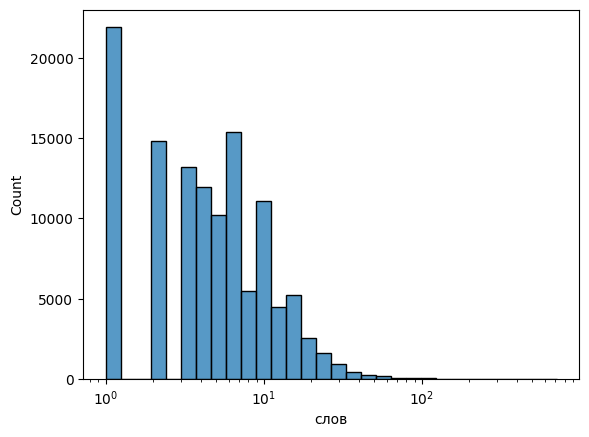

In [7]:
uni["слов"] = uni.text.fillna("").str.split().apply(len)
med = int(uni[uni["слов"] > 0]["слов"].median()) #есть удаленные сообщения с 0 слов например

sns.histplot(uni[uni.слов > 0].слов, log_scale=True, bins=30)

In [8]:
print(med, "медиана")

4 медиана


<Axes: ylabel='kind'>

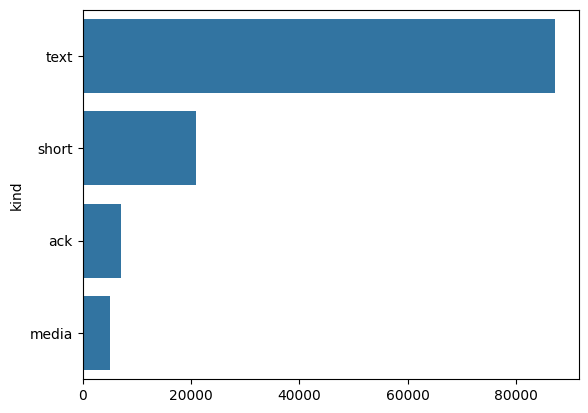

In [9]:
vc = uni.kind.value_counts()
sns.barplot(x=vc.values, y=vc.index)

Большая часть содержательная, но много мусора (да/ + / спс и тд)

Логично что вектор одного сообщения useless - надо брать с контекстом (например - на те на которые ссылается сообщение + n вокруг (от самого сообщения и от сылок))

Примерно так и получили наши "умные" эмбединги 

(просто в трансформер небольшой закидывается сообщение + контекст (не весь корпус), прогоняется через слои и "умный эмбединг" - средний эмбединг по токенам, соответств изнач сообщению)


Далее загрузка векторов и нормировка

In [41]:
#vibe code {
ids = json.load(open(f"{dir}/vec/ids_ctx.json"))
row = {u: i for i, u in enumerate(ids)}
B = np.load(f"{dir}/vec/dense_ctx.f16.npy").astype(np.float32)
B /= np.linalg.norm(B, axis=1, keepdims=True) + 1e-9
#}


In [42]:
len(B)

120127

<Axes: ylabel='Count'>

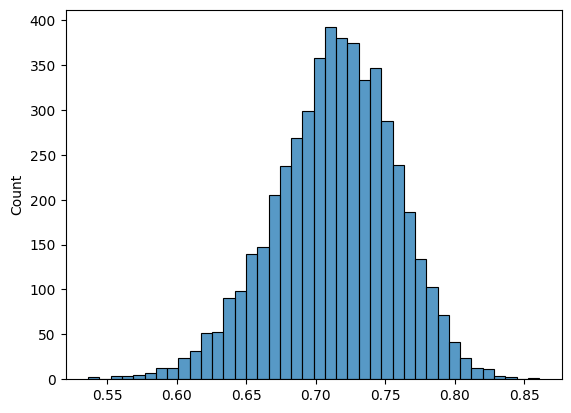

In [43]:
a, b = np.random.randint(0, len(B), 5000), np.random.randint(0, len(B), 5000)
cos = (B[a] * B[b]).sum(1)
sns.histplot(cos, bins=40)
#случайные вектора, кос сходство 

In [13]:
#все вектора +- близки к друг другу, а не ортогональны

### пробуем HDBSCAN 

кластеров 0, доля 'шума' = 1.0


<Axes: ylabel='None'>

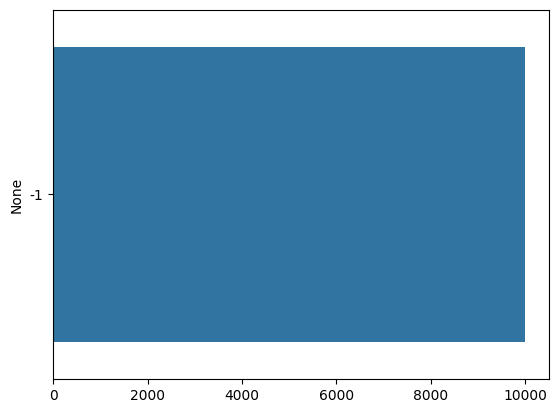

In [44]:
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN

sub = np.random.choice(len(B), 10000, replace=False)
pca = PCA(50, random_state=0).fit_transform(B[sub] - B[sub].mean(0)) #базовая предобработка
h = HDBSCAN(min_cluster_size=50).fit_predict(pca)

noise = (h == -1).mean()
print(f"кластеров {len(set(h)) - 1}, доля 'шума' = {noise}")

sns.barplot(
    x=pd.Series(h).value_counts().values, 
    y=pd.Series(h).value_counts().index.astype(str)
)

Плотность тут не работает.

вспомним олимпиадный прием whiten=True - подгоняет все дисперсии под 1

кластеров 0, доля 'шума' = 1.0


<Axes: ylabel='None'>

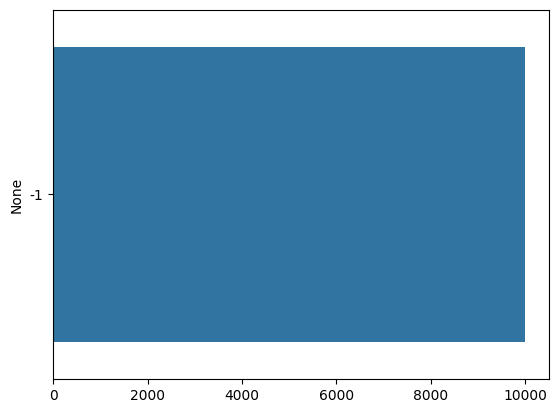

In [45]:
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN

sub = np.random.choice(len(B), 10000, replace=False)
pca = PCA(50, random_state=0, whiten=True).fit_transform(B[sub] - B[sub].mean(0)) #базовая предобработка
h = HDBSCAN(min_cluster_size=50).fit_predict(pca)

noise = (h == -1).mean()
print(f"кластеров {len(set(h)) - 1}, доля 'шума' = {noise}")

sns.barplot(
    x=pd.Series(h).value_counts().values, 
    y=pd.Series(h).value_counts().index.astype(str)
)

In [46]:
#тут не работает 

кластеров 49


<Axes: ylabel='None'>

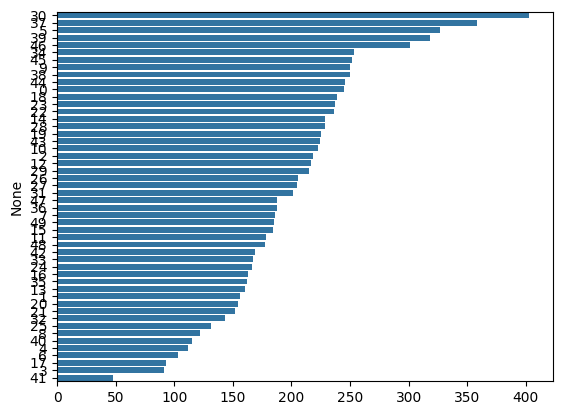

In [59]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sub = np.random.choice(len(B), 10000, replace=False)
pca = PCA(50, random_state=0, whiten=True).fit(B[sub] - B[sub].mean(0)) #базовая предобработка
h = KMeans(50, n_init=10, random_state=0).fit_predict(pca.transform(B[sub] - B[sub].mean(0)))

print(f"кластеров {len(set(h)) - 1}")

sns.barplot(
    x=pd.Series(h).value_counts().values, 
    y=pd.Series(h).value_counts().index.astype(str)
)

In [48]:
#а вот тут работает хорошо

Посмотрим на 2D, раскрасим 7 самых больших тем

In [60]:
#пару удобных статистик еще
cont = uni[uni["kind"] == "text"]["unit_id"]
ri = np.array([row[u] for u in cont])
mean = B[ri].mean(0)

pca = PCA(50, whiten=True, random_state=0).fit(B[ri] - mean)
Xw = pca.transform(B[ri] - mean) 
km = KMeans(50, n_init=10, random_state=0).fit(Xw)
sizes = pd.Series(km.labels_).value_counts()

<Axes: xlabel='x', ylabel='y'>

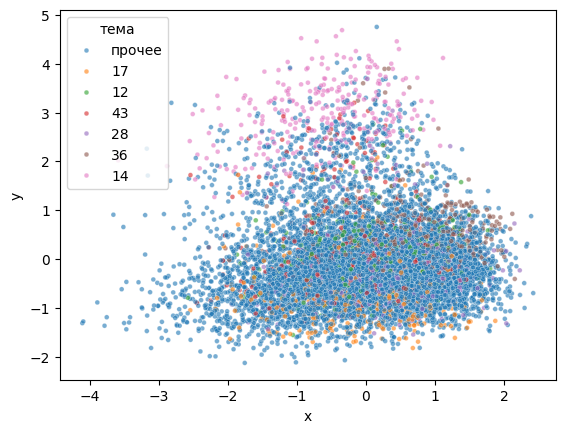

In [61]:
top6 = sizes.index[:6]
s = np.random.choice(len(ri), 10000, replace=False)

d2 = pd.DataFrame({
    "x": Xw[s, 0], 
    "y": Xw[s, 1],
    "тема": [str(l) if l in set(top6) else "прочее" for l in km.labels_[s]]
})

sns.scatterplot(data=d2, x="x", y="y", hue="тема", s=12, alpha=.6)

<Axes: xlabel='x', ylabel='y'>

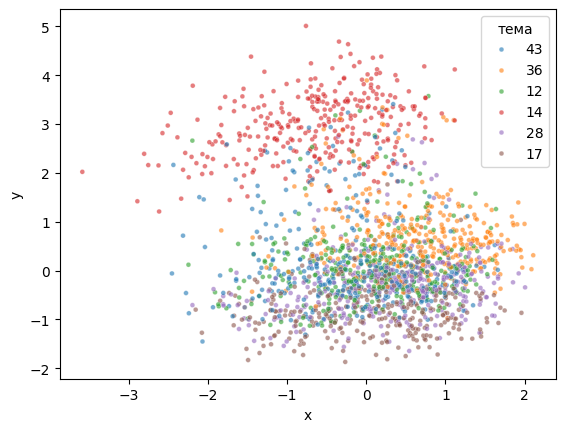

In [62]:
#без прочего

top6 = sizes.index[:6]
s = np.random.choice(len(ri), 10000, replace=False)

d2 = pd.DataFrame({
    "x": Xw[s, 0], 
    "y": Xw[s, 1],
    "тема": [str(l) for l in km.labels_[s]]
})

d2 = d2[d2["тема"].isin(top6.astype(str))]

sns.scatterplot(data=d2, x="x", y="y", hue="тема", s=12, alpha=.6)

In [21]:
#что-то тут видно

Посмотрим какие сообщения в кластерах

In [84]:
#vibe code{
text = uni.set_index("unit_id")["text"]     # unit_id -> текст, один раз (а не в каждой итерации)
contv = np.asarray(cont)                     # чтоб индексировать позиционно, а не по метке

def reps(c, n=3):
    idx = np.where(km.labels_ == c)[0]                     # позиции content-реплик кластера c
    d = np.linalg.norm(Xw[idx] - km.cluster_centers_[c], axis=1)
    nearest = idx[np.argsort(d)[:n]]                       # n ближайших к центру
    return [text[contv[i]] for i in nearest]

pd.DataFrame({f"cluster {top6[0]}": reps(top6[0]), f"cluster {top6[1]}": reps(top6[1])})
#}

,cluster 36,cluster 28
0,ну это для обычных смертных,"Да, достаточно много"
1,С последней обновы,В чем прикол равноденствия
2,Один в один\nТок без галки,Говорун ещё может быть


## Мечта - разложить весь корпус по темам

В идеале - просто в ЛЛМку сувать сообщение (и промт типа - вот такие у нас есть кластера, вот такие там 100% лежат сообщения - разметь эту пж)

Нюанс - реплики могут быть несодержательны + точка может находиться сразу на границе нескольких кластеров и даже ЛЛМка на рандом будет тогда ее отправлять

Потому можно проверить насколько близки сами кластера (по косинусу)

<Axes: ylabel='Count'>

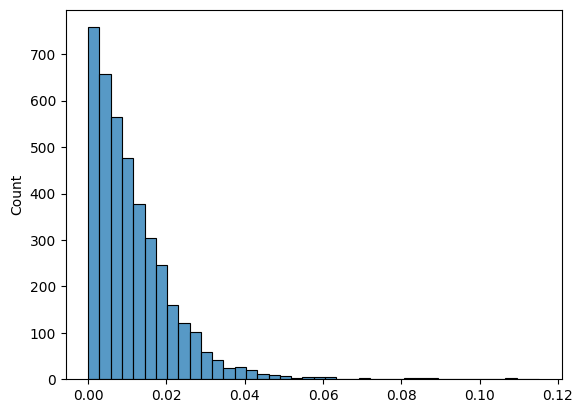

In [72]:

centers = []
for c in range(50):
    points = B[ri][km.labels_ == c]
    centers.append(points.mean(axis=0))

cen = np.array(centers)
lens = np.linalg.norm(cen, axis=1, keepdims=True) #нормируем
cen = cen / (lens + 1e-9) # на всякий случай

smp = np.random.choice(len(B), size=4000, replace=False) #берем рандомные вектора 

b_smp = B[smp]
b_smp_lens = np.linalg.norm(b_smp, axis=1, keepdims=True)
b_smp = b_smp / (b_smp_lens + 1e-9)


scores = b_smp @ cen.T #все со всеми
sorted_scores = np.sort(scores, axis=1) 


gap = sorted_scores[:, -1] - sorted_scores[:, -2] #разница для вектора между топ 1 и топ 2
sns.histplot(gap, bins=40)



In [73]:
#то есть всреднем ближайший кластер топ 1 и топ 2 очень близки в обычнм пространстве (что мы уже получали)

проверим в нормированном пространстве

<Axes: ylabel='Count'>

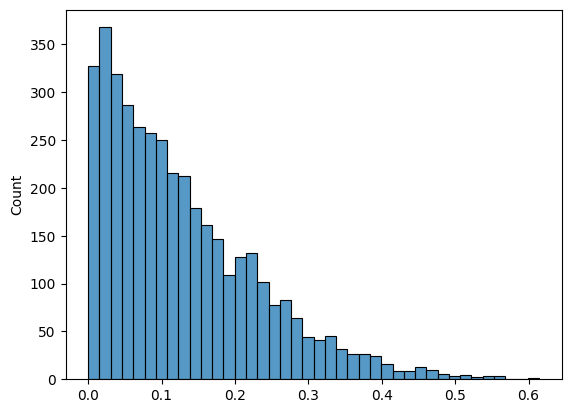

In [74]:


B_pca = pca.transform(B - B.mean(axis=0))

centers = []
for c in range(50):
    points = B_pca[ri][km.labels_ == c]
    centers.append(points.mean(axis=0))

cen = np.array(centers)
lens = np.linalg.norm(cen, axis=1, keepdims=True)
cen = cen / (lens + 1e-9)

smp = np.random.choice(len(B_pca), size=4000, replace=False)

b_smp = B_pca[smp]
b_smp_lens = np.linalg.norm(b_smp, axis=1, keepdims=True)
b_smp = b_smp / (b_smp_lens + 1e-9)

scores = b_smp @ cen.T 
sorted_scores = np.sort(scores, axis=1) 

gap = sorted_scores[:, -1] - sorted_scores[:, -2]
sns.histplot(gap, bins=40)

In [75]:
#Конечно все тож вокруг нуля но на 2 порядка лучше!

## Попробуем что-то обучить

50 подтем на одно короткое сообщение сложно + шум большой. можно взять например 7 крупных тем. через геометрию их разметить не надежно, потому сделаем дешевую разметку LLMкой:

1.крошечный train (2000 реплик) заранее размечен LLM в 7 тем

2.на нем учим  простейший линейный классификатор - и метим им весь корпус.

Сначала посмотрим на трейн - какие классы и насколько они несбалансированы.

+закинем N представителей мега кластеров в LLM - она назовет кластера по сообщениям в нем 

In [78]:
#внешне нейронка разметила, во внешний файлик сохранено (см доку)
#vibe code:
train = [s for s in map(json.loads, open(f"{dir}/topics/seed_labeled.jsonl")) if s["unit_id"] in row] 
Xs = B[[row[s["unit_id"]] for s in train]]
ys = np.array([s["megas"][0] for s in train])
vc = pd.Series(ys).value_counts()

In [79]:
ys

array(['Боты и игры', 'Оффтоп/болтовня', 'Разбор задач', ..., 'others',
       'others', 'others'], dtype='<U24')

In [80]:
vc

others                      603
Оффтоп/болтовня             580
Баллы и апелляции           192
Разбор задач                165
Боты и игры                 124
Мета                        118
Логистика и быт             111
Поступление и подготовка    107
Name: count, dtype: int64

<Axes: ylabel='None'>

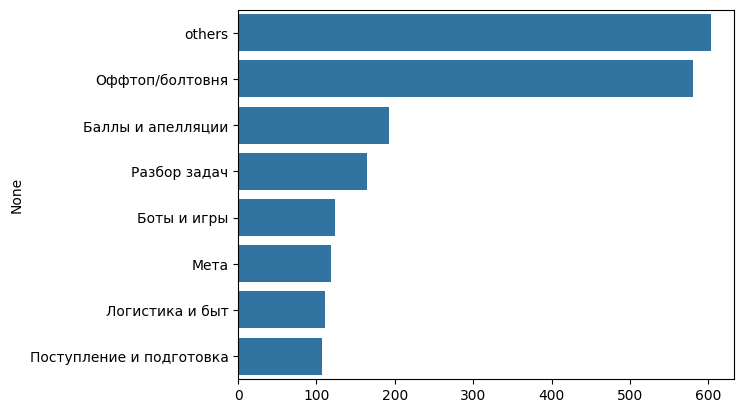

In [81]:

sns.barplot(x=vc.values, y=vc.index)

Дисбаланс классов - нужны хитрые методы, Проверим несколько моделей кроссвалом 

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from sklearn.svm import LinearSVC

#параметры из головы, но это бейзлайн
logreg = LogisticRegression(max_iter=2000, C=1, class_weight="balanced")
knn = KNeighborsClassifier(15) 
cb = CatBoostClassifier(verbose=50, iterations=50)
svс = LinearSVC(C=0.5, class_weight="balanced")

Learning rate set to 0.5
0:	learn: 1.8266431	total: 417ms	remaining: 20.4s
49:	learn: 0.4242329	total: 6.39s	remaining: 0us
Learning rate set to 0.5
0:	learn: 1.8014541	total: 139ms	remaining: 6.82s
49:	learn: 0.4083087	total: 7.1s	remaining: 0us
Learning rate set to 0.5
0:	learn: 1.8084282	total: 138ms	remaining: 6.75s
49:	learn: 0.4153444	total: 8.93s	remaining: 0us
Learning rate set to 0.5
0:	learn: 1.8124830	total: 157ms	remaining: 7.7s
49:	learn: 0.4233031	total: 6.94s	remaining: 0us
Learning rate set to 0.5
0:	learn: 1.7939211	total: 142ms	remaining: 6.95s
49:	learn: 0.3945932	total: 6.43s	remaining: 0us


<Axes: >

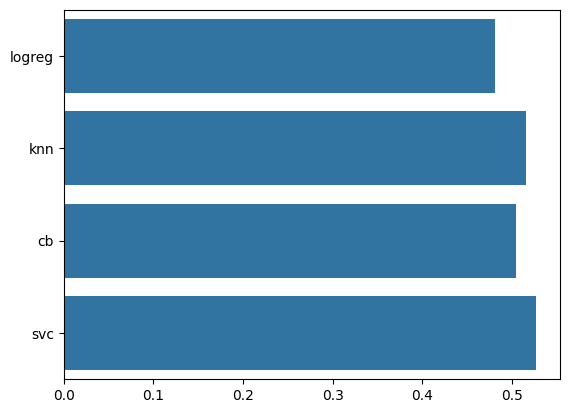

In [83]:

from sklearn.model_selection import cross_val_score


models = {"logreg": logreg, 
          "knn": knn,
          "cb": cb,
          "svс": svс}



acc = {n: cross_val_score(m, Xs, ys, cv=5).mean() for n, m in models.items()}

sns.barplot(x=list(acc.values()), y=list(acc.keys()))

In [34]:
# +- норм аккурси так как классов 8 (7 меток + мусор)

LinearSVC лучше всех, ее и берем. Посмотрим, где она путается на confusion матрице

<Axes: >

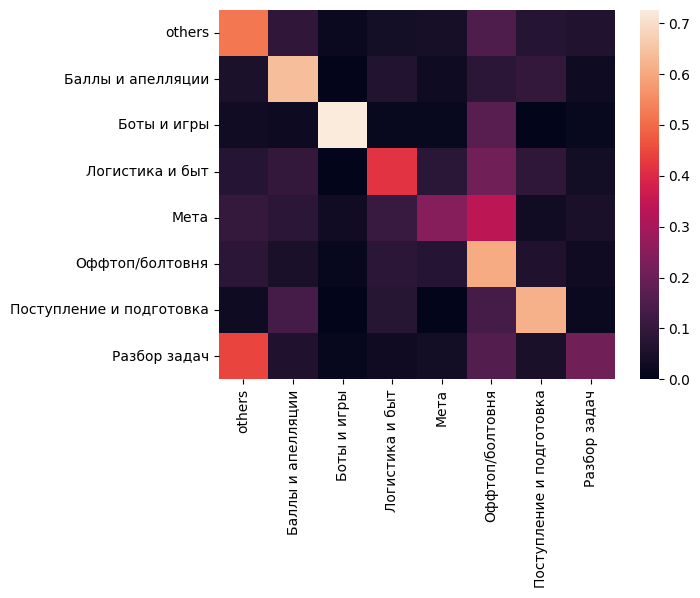

In [85]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

svc = LinearSVC(C=0.5, class_weight="balanced")
yp = cross_val_predict(svc, Xs, ys, cv=5)
t = sorted(set(ys))

cm = confusion_matrix(ys, yp, labels=t, normalize="true")
sns.heatmap(cm, xticklabels=t, yticklabels=t)

оффтоп путают со всеми, а еще рабор задач с others

# Еще более глобально

Понятно что оценка на точках train хорошая - нужно сделать оценку на новой выборке

+попробуем сделать еще более большие кластеры до 3 тем (учеба / соц / прочее) - будет иерархическая такая кластеризация


In [ ]:
SUPER = {"Баллы и апелляции": "учеба", "Разбор задач": "учеба", "Поступление и подготовка": "учеба",
         "Логистика и быт": "учеба", "Мета": "учеба", "Оффтоп/болтовня": "соц",
         "Боты и игры": "соц", "others": "прочее"}


svc.fit(Xs, ys)

LinearSVC(C=0.5, class_weight='balanced')

In [37]:
#загрузка val выборки

In [88]:
#vibe coded {
ev = [e for e in map(json.loads, open(f"{dir}/topics/eval_labeled.jsonl")) if e["unit_id"] in row] 
Xe = B[[row[e["unit_id"]] for e in ev]]
ye = np.array([e["megas"][0] for e in ev])
#}

In [89]:
pred = svc.predict(Xe)

base_acc = pd.Series(ye).value_counts(normalize=True).max() # самый популярный класс доля

mega_acc = (pred == ye).mean()
super_pred = [SUPER.get(p, "прочее") for p in pred]
super_otveti = [SUPER.get(t, "прочее") for t in ye]
super_acc = (np.array(super_pred) == np.array(super_otveti)).mean()

самый популярный класс 0.296 | 7 тем 0.47 | 3 класса 0.612


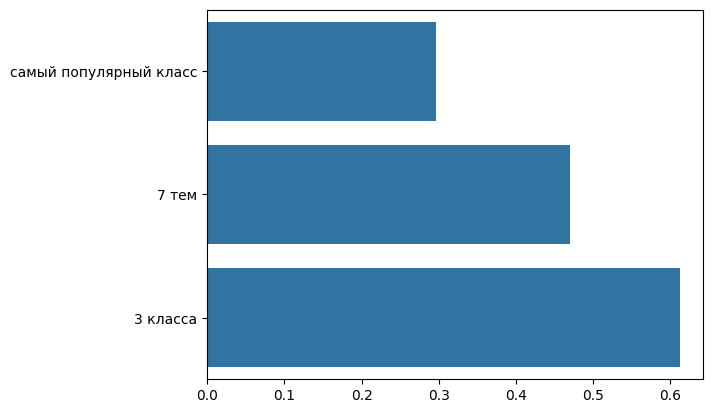

In [90]:
sns.barplot(x=[base_acc, mega_acc, super_acc],
            y=["самый популярный класс", "7 тем", "3 класса"])
print(f"самый популярный класс {base_acc} | 7 тем {mega_acc} | 3 класса {super_acc}")

Таким образом, если брать самое грубое разбиение на классы - получается вменяемая точность

если чуть более мелкое - будет неуверенная моделька (+даже человеку сложно будет различить между темами)

# Собираем финальные метки

Метим весь корпус супермоделью нашей + кластера 

Итого: 3 уровня разметки
50 -> 7+1 -> 3

In [95]:
#vibecoded {
D = km.transform(pca.transform(B - mean)) 
subtopic = D.argmin(1)                        
d1 = D.min(1)                               
others_geo = d1 > np.percentile(d1, 95)
p1 = svc.decision_function(B)
p1 = 1 / (1 + np.exp(-p1))
if p1.ndim == 1: p1 = np.vstack([1 - p1, p1]).T
c1 = p1.argmax(1)
conf_m = p1.max(1)
mega = np.where((conf_m < 0.35) | (svc.classes_[c1] == "others"), "others", svc.classes_[c1])
final = pd.DataFrame({"unit_id": ids, "super": [SUPER.get(m, "else") for m in mega],
                      "mega": mega, "subtopic": np.where(others_geo, -1, subtopic), "conf": conf_m.round(3)})
final.to_json(f"{dir}/topics/labels_final_nb.jsonl", orient="records", lines=True, force_ascii=False)
#}

In [96]:
final

,unit_id,super,mega,subtopic,conf
0,0,учёба,Разбор задач,3,0.374
1,1,учёба,Разбор задач,-1,0.475
2,2,учёба,Разбор задач,-1,0.492
3,3,учёба,Разбор задач,-1,0.459
4,4,учёба,Разбор задач,-1,0.437
...,...,...,...,...,...
120122,120122,соц,Оффтоп/болтовня,26,0.442
120123,120123,соц,Оффтоп/болтовня,14,0.441
120124,120124,соц,Оффтоп/болтовня,7,0.457
120125,120125,соц,Оффтоп/болтовня,26,0.407


In [97]:
t = final.groupby(by="mega")["unit_id"].count().reset_index()
t = t.sort_values(by="unit_id")
t

,mega,unit_id
2,Боты и игры,3421
7,Разбор задач,6548
4,Мета,7950
3,Логистика и быт,9624
6,Поступление и подготовка,13226
1,Баллы и апелляции,14105
0,others,24158
5,Оффтоп/болтовня,41095


<Axes: xlabel='unit_id', ylabel='mega'>

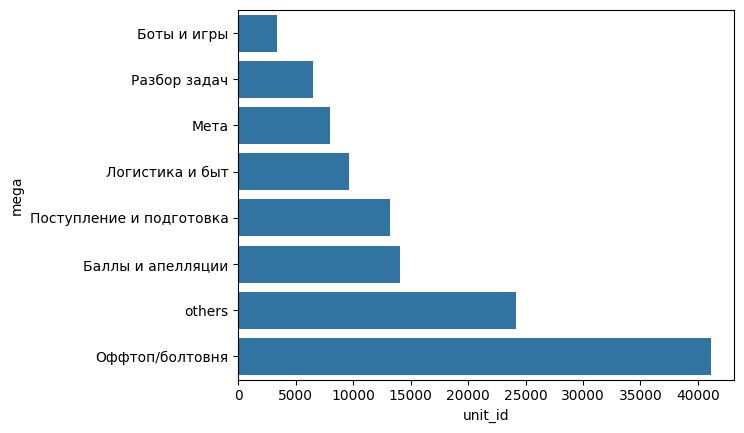

In [98]:

sns.barplot(y=t["mega"], x=t["unit_id"])

Пример живых сообщений 

In [99]:
show = final.merge(uni[["unit_id", "text"]], on="unit_id")
show[show.text.str.len().between(15, 70)].sample(6, random_state=3)[["super", "mega", "text"]]


,super,mega,text
90567,учёба,Баллы и апелляции,"Обычно от москвы 50 берут, а щас еще увеличили..."
116284,учёба,Мета,Маскау так просто не выдаст\nМы братья
35019,учёба,Баллы и апелляции,ну пусть пока примерные будут
41835,учёба,Баллы и апелляции,"Лол, у нас выплаты до 10к"
8334,прочее,others,лучшая задача была
29331,соц,Оффтоп/болтовня,когда нагробили по полной


## устойчивы ли 50 кластеров + почему столько

Померим стандартную метрику ARI для разных количеств кластеров

In [103]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score as ARI

cont = [row[u] for u, ck in zip(df["unit_id"], df["content_kind"]) if ck == "text"]
Xc = B[cont] - B[cont].mean(0)

def fit(k, X):
    p = PCA(50, whiten=True).fit(X)
    km = KMeans(k, n_init=3).fit(p.transform(X))
    return p, km

rows = []
for k in [10, 20, 50, 100, 200]:
    pA, kmA = fit(k, Xc)
    sub = np.random.choice(len(Xc), int(0.7 * len(Xc)), replace=False)
    pB, kmB = fit(k, Xc[sub])

    labA = kmA.predict(pA.transform(Xc))
    labB = kmB.predict(pB.transform(Xc)) 

    rows.append({"k": k, "ARI": ARI(labA, labB), "elems": len(Xc) // k})
rows = pd.DataFrame(rows)

rows

,k,ARI,elems
0,10,0.170878,8584
1,20,0.530476,4292
2,50,0.644684,1716
3,100,0.527053,858
4,200,0.417521,429


<Axes: xlabel='k', ylabel='ARI'>

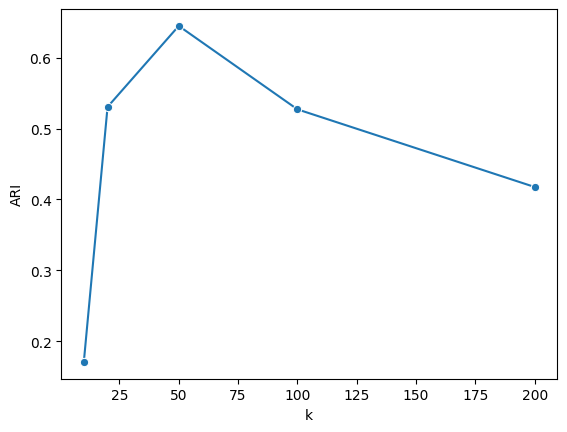

In [104]:
sns.lineplot(data=rows, x="k", y="ARI", marker="o")

<Axes: xlabel='k', ylabel='elems'>

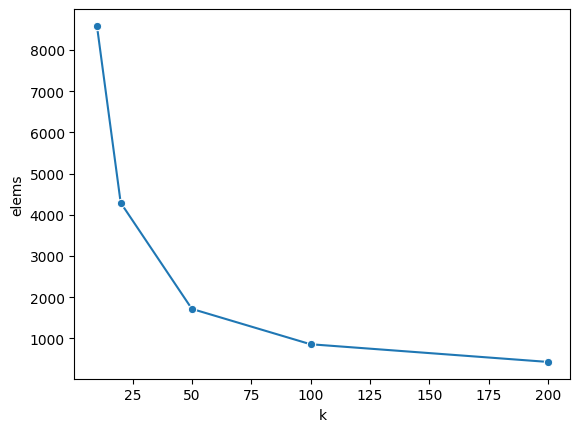

In [105]:
sns.lineplot(data=rows, x="k", y="elems", marker="o")

По методу локтя 50+- оптимально тут - короче 50 - отличное число

## Итоги

1. сообщения маленькие - векторизуем с контекстом
2. пространство сжато в конус - плотностная кластеризация (HDBSCAN) разваливается
3. нормализация дисперсии чинит геометрию - 50 ровных подтем
4. считаем кластера в нормализованном пространстве
5. на короткое сообщение крупную тему ставит линейная моделька по разметке LLMки
6. потолок ~46% на 7 темах - потому три уровня (super ~60% / mega / subtopic)

Метки завайбкожены (labels_final_nb.jsonl). Далее будем с ними работать